# Projeto: Perceptron Manual com 2 Entradas + Bias - Base Iris

## Objetivo
Neste notebook, será implementado um **Perceptron manual**, sem uso de NumPy ou bibliotecas de machine learning.

## Sobre a base Iris

A base Iris é um dataset clássico da área de Aprendizagem de Máquina.  
Ela contém medidas de flores de três espécies diferentes de íris:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

Para cada flor, a base traz medidas numéricas relacionadas às pétalas e sépalas, como comprimento e largura.

Essa base é muito utilizada em problemas introdutórios de classificação, pois possui dados simples de entender e facilita a visualização em gráficos.


## Justificativa da escolha dessa base

A base **Iris** foi escolhida porque possui dados numéricos bem organizados, classes conhecidas e boa separação visual entre algumas espécies.

Ela é adequada para a proposta do trabalho porque permite implementar um Perceptron manual com duas entradas e bias de forma simples, além de possibilitar a análise gráfica dos dados escolhidos, facilitando a interpretação do funcionamento do modelo.

Além disso,é uma base bastante conhecida em Aprendizagem de Máquina por sua simplicidade, e segue o enunciado da atividade proposta:

- usar uma base do Kaggle
- criar um Perceptron com **no mínimo 2 entradas + bias**
- implementar tudo manualmente
- mostrar detalhes do dataset
- gerar gráficos
- destacar as entradas escolhidas
- mostrar a função do Perceptron e exemplos de funcionamento


## Organização do notebook

Este notebook foi organizado de forma simples e direta:

1. Importações
2. Leitura manual do CSV
3. Exploração básica do dataset
4. Escolha das entradas do Perceptron
5. Preparação da base binária
6. Gráficos das classes escolhidas
7. Função do Perceptron
8. Treinamento manual
9. Testes do modelo
10. Gráficos de desempenho e fronteira de decisão
11. Conclusão


## Base utilizada

Base: **Iris**

Arquivo esperado na mesma pasta do notebook:
- `Iris.csv`

Colunas principais:
- `SepalLengthCm`
- `SepalWidthCm`
- `PetalLengthCm`
- `PetalWidthCm`
- `Species`

Neste projeto, o problema será transformado em **classificação binária**:

- `Iris-setosa` = 1
- `Iris-versicolor` = 0

A classe `Iris-virginica` será deixada de fora para manter o Perceptron simples e alinhado ao enunciado.


In [1]:
import csv
import math
import random
import statistics
from collections import Counter
import matplotlib.pyplot as plt


In [2]:
NOME_ARQUIVO_CSV = "Iris.csv"


## Leitura manual do CSV

A seguir, o arquivo será lido com `csv.DictReader`, sem uso de pandas.


In [3]:
dados = []

with open(NOME_ARQUIVO_CSV, "r", encoding="utf-8") as arquivo:
    leitor = csv.DictReader(arquivo)
    for linha in leitor:
        dados.append({
            "Id": int(linha["Id"]),
            "SepalLengthCm": float(linha["SepalLengthCm"]),
            "SepalWidthCm": float(linha["SepalWidthCm"]),
            "PetalLengthCm": float(linha["PetalLengthCm"]),
            "PetalWidthCm": float(linha["PetalWidthCm"]),
            "Species": linha["Species"]
        })

print("Quantidade total de registros:", len(dados))
print("Primeiro registro:")
print(dados[0])
print("Segundo registro:")
print(dados[1])


Quantidade total de registros: 150
Primeiro registro:
{'Id': 1, 'SepalLengthCm': 5.1, 'SepalWidthCm': 3.5, 'PetalLengthCm': 1.4, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}
Segundo registro:
{'Id': 2, 'SepalLengthCm': 4.9, 'SepalWidthCm': 3.0, 'PetalLengthCm': 1.4, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}


## Visão geral do dataset


In [4]:
nomes_colunas = list(dados[0].keys())

print("Colunas encontradas:")
for nome in nomes_colunas:
    print("-", nome)


Colunas encontradas:
- Id
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm
- Species


In [5]:
classes = [item["Species"] for item in dados]
contagem_classes = Counter(classes)

print("Distribuição das classes:")
for classe, quantidade in contagem_classes.items():
    print(classe, "->", quantidade)


Distribuição das classes:
Iris-setosa -> 50
Iris-versicolor -> 50
Iris-virginica -> 50


In [6]:
print("Amostras iniciais do dataset:")
for item in dados[:5]:
    print(item)


Amostras iniciais do dataset:
{'Id': 1, 'SepalLengthCm': 5.1, 'SepalWidthCm': 3.5, 'PetalLengthCm': 1.4, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}
{'Id': 2, 'SepalLengthCm': 4.9, 'SepalWidthCm': 3.0, 'PetalLengthCm': 1.4, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}
{'Id': 3, 'SepalLengthCm': 4.7, 'SepalWidthCm': 3.2, 'PetalLengthCm': 1.3, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}
{'Id': 4, 'SepalLengthCm': 4.6, 'SepalWidthCm': 3.1, 'PetalLengthCm': 1.5, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}
{'Id': 5, 'SepalLengthCm': 5.0, 'SepalWidthCm': 3.6, 'PetalLengthCm': 1.4, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}


## Resumo estatístico simples das features numéricas


In [7]:
def resumo_numerico(dados, nome_coluna):
    valores = [item[nome_coluna] for item in dados]
    return {
        "mínimo": min(valores),
        "máximo": max(valores),
        "média": round(statistics.mean(valores), 4),
        "mediana": round(statistics.median(valores), 4)
    }

colunas_numericas = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

for coluna in colunas_numericas:
    print("\nResumo da coluna:", coluna)
    print(resumo_numerico(dados, coluna))



Resumo da coluna: SepalLengthCm
{'mínimo': 4.3, 'máximo': 7.9, 'média': 5.8433, 'mediana': 5.8}

Resumo da coluna: SepalWidthCm
{'mínimo': 2.0, 'máximo': 4.4, 'média': 3.054, 'mediana': 3.0}

Resumo da coluna: PetalLengthCm
{'mínimo': 1.0, 'máximo': 6.9, 'média': 3.7587, 'mediana': 4.35}

Resumo da coluna: PetalWidthCm
{'mínimo': 0.1, 'máximo': 2.5, 'média': 1.1987, 'mediana': 1.3}


## Escolha das entradas do Perceptron

As duas entradas escolhidas foram:

- `PetalLengthCm`
- `PetalWidthCm`

Essas duas variáveis costumam separar muito bem as classes `Iris-setosa` e `Iris-versicolor` em um gráfico 2D, o que é ideal para um Perceptron simples.


In [8]:
base_binaria = []

for item in dados:
    if item["Species"] == "Iris-setosa":
        base_binaria.append({
            "x1": item["PetalLengthCm"],
            "x2": item["PetalWidthCm"],
            "classe": 1,
            "species_original": item["Species"]
        })
    elif item["Species"] == "Iris-versicolor":
        base_binaria.append({
            "x1": item["PetalLengthCm"],
            "x2": item["PetalWidthCm"],
            "classe": 0,
            "species_original": item["Species"]
        })

print("Quantidade de registros na base binária:", len(base_binaria))
print("Primeiros 5 registros da base binária:")
for item in base_binaria[:5]:
    print(item)


Quantidade de registros na base binária: 100
Primeiros 5 registros da base binária:
{'x1': 1.4, 'x2': 0.2, 'classe': 1, 'species_original': 'Iris-setosa'}
{'x1': 1.4, 'x2': 0.2, 'classe': 1, 'species_original': 'Iris-setosa'}
{'x1': 1.3, 'x2': 0.2, 'classe': 1, 'species_original': 'Iris-setosa'}
{'x1': 1.5, 'x2': 0.2, 'classe': 1, 'species_original': 'Iris-setosa'}
{'x1': 1.4, 'x2': 0.2, 'classe': 1, 'species_original': 'Iris-setosa'}


In [9]:
entradas = []
saidas = []

for item in base_binaria:
    entradas.append([item["x1"], item["x2"]])
    saidas.append(item["classe"])

print("Quantidade de entradas:", len(entradas))
print("Quantidade de saídas:", len(saidas))
print("\nPrimeiras 5 entradas:")
for entrada in entradas[:5]:
    print(entrada)

print("\nPrimeiras 5 saídas:")
for saida in saidas[:5]:
    print(saida)


Quantidade de entradas: 100
Quantidade de saídas: 100

Primeiras 5 entradas:
[1.4, 0.2]
[1.4, 0.2]
[1.3, 0.2]
[1.5, 0.2]
[1.4, 0.2]

Primeiras 5 saídas:
1
1
1
1
1


## Gráfico principal das duas classes escolhidas


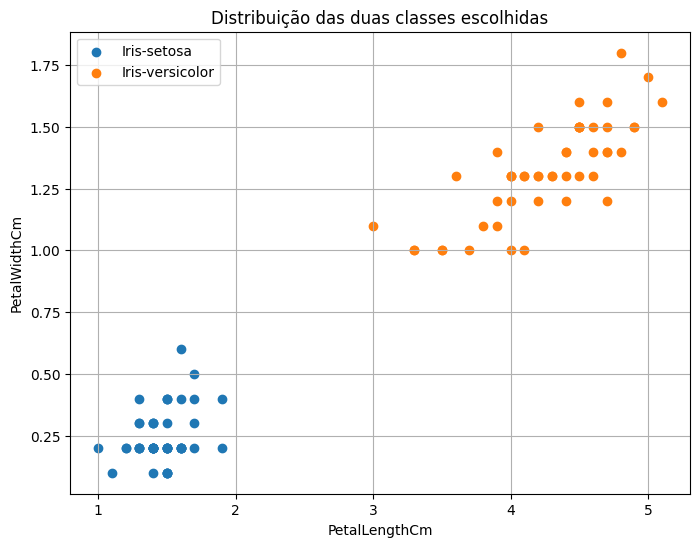

In [10]:
x_setosa = []
y_setosa = []
x_versicolor = []
y_versicolor = []

for item in base_binaria:
    if item["classe"] == 1:
        x_setosa.append(item["x1"])
        y_setosa.append(item["x2"])
    else:
        x_versicolor.append(item["x1"])
        y_versicolor.append(item["x2"])

plt.figure(figsize=(8, 6))
plt.scatter(x_setosa, y_setosa, label="Iris-setosa")
plt.scatter(x_versicolor, y_versicolor, label="Iris-versicolor")
plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")
plt.title("Distribuição das duas classes escolhidas")
plt.legend()
plt.grid(True)
plt.show()


## Gráficos extras para análise

Os próximos gráficos ajudam a entender melhor os dados escolhidos e reforçam o aprendizado.


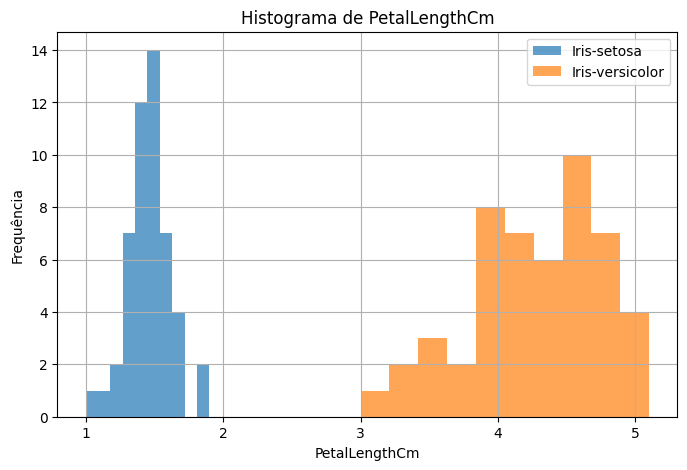

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(x_setosa, bins=10, alpha=0.7, label="Iris-setosa")
plt.hist(x_versicolor, bins=10, alpha=0.7, label="Iris-versicolor")
plt.xlabel("PetalLengthCm")
plt.ylabel("Frequência")
plt.title("Histograma de PetalLengthCm")
plt.legend()
plt.grid(True)
plt.show()


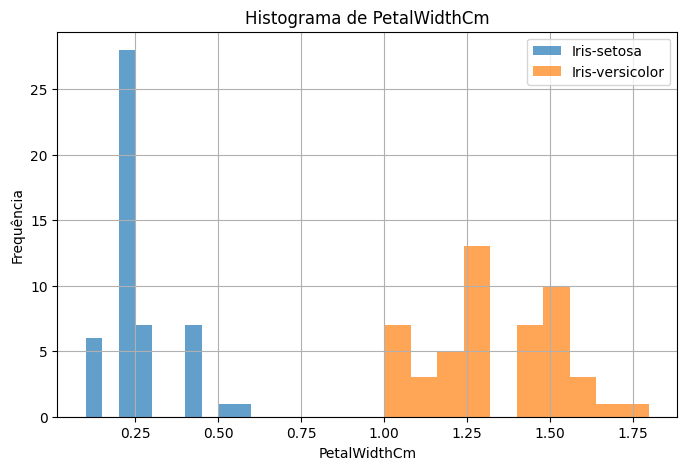

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(y_setosa, bins=10, alpha=0.7, label="Iris-setosa")
plt.hist(y_versicolor, bins=10, alpha=0.7, label="Iris-versicolor")
plt.xlabel("PetalWidthCm")
plt.ylabel("Frequência")
plt.title("Histograma de PetalWidthCm")
plt.legend()
plt.grid(True)
plt.show()


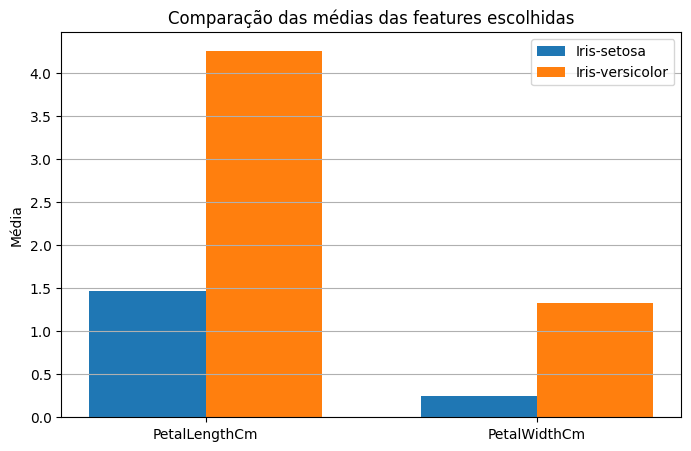

In [13]:
medias_setosa = [statistics.mean(x_setosa), statistics.mean(y_setosa)]
medias_versicolor = [statistics.mean(x_versicolor), statistics.mean(y_versicolor)]

nomes_features = ["PetalLengthCm", "PetalWidthCm"]
posicoes = [0, 1]
largura = 0.35

plt.figure(figsize=(8, 5))
plt.bar([p - largura/2 for p in posicoes], medias_setosa, width=largura, label="Iris-setosa")
plt.bar([p + largura/2 for p in posicoes], medias_versicolor, width=largura, label="Iris-versicolor")
plt.xticks(posicoes, nomes_features)
plt.ylabel("Média")
plt.title("Comparação das médias das features escolhidas")
plt.legend()
plt.grid(True, axis="y")
plt.show()


## Função do Perceptron

A lógica utilizada é:

1. multiplicar cada entrada pelo seu peso
2. somar os resultados
3. adicionar o bias
4. aplicar a função degrau

Equação:
- `z = (x1 * w1) + (x2 * w2) + bias`

Regra:
- se `z >= 0`, a saída é `1`
- se `z < 0`, a saída é `0`

## Onde a equação do Perceptron foi usada

A equação do Perceptron: foi implementada dentro da função `prever()`.

No código:
- `amostra[i]` representa a entrada (`x1`, `x2`)
- `pesos[i]` representa os pesos (`w1`, `w2`)
- `bias` representa o termo de ajuste final
- `soma` representa exatamente o valor de `z`

Ou seja, a variável `soma` é a implementação prática da equação do Perceptron.


In [14]:
def funcao_degrau(valor):
    if valor >= 0:
        return 1
    return 0


def prever(amostra, pesos, bias):
    soma = 0

    for i in range(len(amostra)):
        soma += amostra[i] * pesos[i]

    soma += bias
    saida = funcao_degrau(soma)

    return saida, soma


## Teste inicial da função de previsão

Antes do treinamento, é interessante testar a função com pesos arbitrários.


In [15]:
pesos_teste = [0.5, 0.5]
bias_teste = -1.0

amostra_teste = entradas[0]
classe_prevista, soma = prever(amostra_teste, pesos_teste, bias_teste)

print("Amostra:", amostra_teste)
print("Soma ponderada:", soma)
print("Classe prevista:", classe_prevista)
print("Classe real:", saidas[0])


Amostra: [1.4, 0.2]
Soma ponderada: -0.20000000000000007
Classe prevista: 0
Classe real: 1


## Testes extras da função de previsão

Esses testes ajudam a observar o comportamento da função do Perceptron antes do treinamento final.


In [16]:
indices_teste = [0, 10, 25, 50, 75]

for indice in indices_teste:
    amostra = entradas[indice]
    classe_real = saidas[indice]
    classe_prevista, soma = prever(amostra, pesos_teste, bias_teste)

    print("Índice:", indice)
    print("Amostra:", amostra)
    print("Soma:", soma)
    print("Classe prevista:", classe_prevista)
    print("Classe real:", classe_real)
    print("-" * 40)


Índice: 0
Amostra: [1.4, 0.2]
Soma: -0.20000000000000007
Classe prevista: 0
Classe real: 1
----------------------------------------
Índice: 10
Amostra: [1.5, 0.2]
Soma: -0.15000000000000002
Classe prevista: 0
Classe real: 1
----------------------------------------
Índice: 25
Amostra: [1.6, 0.2]
Soma: -0.09999999999999998
Classe prevista: 0
Classe real: 1
----------------------------------------
Índice: 50
Amostra: [4.7, 1.4]
Soma: 2.05
Classe prevista: 1
Classe real: 0
----------------------------------------
Índice: 75
Amostra: [4.4, 1.4]
Soma: 1.9000000000000004
Classe prevista: 1
Classe real: 0
----------------------------------------


## Treinamento manual do Perceptron


In [17]:
def treinar_perceptron(entradas, saidas, taxa_aprendizado=0.1, epocas=20):
    pesos = [0.0, 0.0]
    bias = 0.0
    historico_erros = []

    for epoca in range(epocas):
        erros_epoca = 0

        for i in range(len(entradas)):
            amostra = entradas[i]
            saida_real = saidas[i]

            saida_prevista, soma = prever(amostra, pesos, bias)
            erro = saida_real - saida_prevista

            if erro != 0:
                erros_epoca += 1

            for j in range(len(pesos)):
                pesos[j] = pesos[j] + taxa_aprendizado * erro * amostra[j]

            bias = bias + taxa_aprendizado * erro

        historico_erros.append(erros_epoca)
        print("Época:", epoca + 1, "| Erros:", erros_epoca, "| Pesos:", pesos, "| Bias:", bias)

    return pesos, bias, historico_erros


In [18]:
pesos_finais, bias_final, historico_erros = treinar_perceptron(
    entradas,
    saidas,
    taxa_aprendizado=0.1,
    epocas=20
)

print("\nPesos finais:", pesos_finais)
print("Bias final:", bias_final)
print("Histórico de erros:", historico_erros)


Época: 1 | Erros: 1 | Pesos: [-0.47000000000000003, -0.13999999999999999] | Bias: -0.1
Época: 2 | Erros: 3 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 3 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 4 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 5 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 6 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 7 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 8 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 9 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 10 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 11 | Erros: 0 | Pesos: [-0.06000000000000008, -0.07999999999999997] | Bias: 0.2
Época: 12 | Erros: 0 | Pesos: [-0.06000000000000008

## Avaliação do modelo treinado


In [19]:
acertos = 0
erros = 0

for i in range(len(entradas)):
    classe_prevista, soma = prever(entradas[i], pesos_finais, bias_final)
    classe_real = saidas[i]

    if classe_prevista == classe_real:
        acertos += 1
    else:
        erros += 1

print("Acertos:", acertos)
print("Erros:", erros)
print("Acurácia:", acertos / len(entradas))


Acertos: 100
Erros: 0
Acurácia: 1.0


## Exemplos do modelo funcionando

A seguir, alguns exemplos de previsão já com o modelo treinado.


In [20]:
for i in range(5):
    classe_prevista, soma = prever(entradas[i], pesos_finais, bias_final)
    print("Amostra:", entradas[i])
    print("Soma:", soma)
    print("Classe prevista:", classe_prevista)
    print("Classe real:", saidas[i])
    print("-" * 40)


Amostra: [1.4, 0.2]
Soma: 0.09999999999999991
Classe prevista: 1
Classe real: 1
----------------------------------------
Amostra: [1.4, 0.2]
Soma: 0.09999999999999991
Classe prevista: 1
Classe real: 1
----------------------------------------
Amostra: [1.3, 0.2]
Soma: 0.1059999999999999
Classe prevista: 1
Classe real: 1
----------------------------------------
Amostra: [1.5, 0.2]
Soma: 0.09399999999999989
Classe prevista: 1
Classe real: 1
----------------------------------------
Amostra: [1.4, 0.2]
Soma: 0.09999999999999991
Classe prevista: 1
Classe real: 1
----------------------------------------


In [21]:
indices_teste_finais = [0, 20, 40, 60, 80]

for indice in indices_teste_finais:
    classe_prevista, soma = prever(entradas[indice], pesos_finais, bias_final)
    print("Índice:", indice)
    print("Amostra:", entradas[indice])
    print("Soma:", soma)
    print("Classe prevista:", classe_prevista)
    print("Classe real:", saidas[indice])
    print("-" * 40)


Índice: 0
Amostra: [1.4, 0.2]
Soma: 0.09999999999999991
Classe prevista: 1
Classe real: 1
----------------------------------------
Índice: 20
Amostra: [1.7, 0.2]
Soma: 0.08199999999999988
Classe prevista: 1
Classe real: 1
----------------------------------------
Índice: 40
Amostra: [1.3, 0.3]
Soma: 0.0979999999999999
Classe prevista: 1
Classe real: 1
----------------------------------------
Índice: 60
Amostra: [3.5, 1.0]
Soma: -0.09000000000000025
Classe prevista: 0
Classe real: 0
----------------------------------------
Índice: 80
Amostra: [3.8, 1.1]
Soma: -0.11600000000000027
Classe prevista: 0
Classe real: 0
----------------------------------------


## Gráfico do histórico de erros


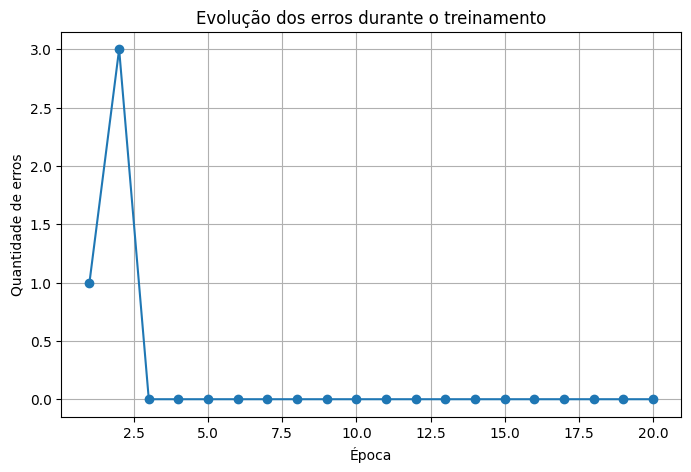

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(historico_erros) + 1), historico_erros, marker="o")
plt.xlabel("Época")
plt.ylabel("Quantidade de erros")
plt.title("Evolução dos erros durante o treinamento")
plt.grid(True)
plt.show()


## Fronteira de decisão do Perceptron


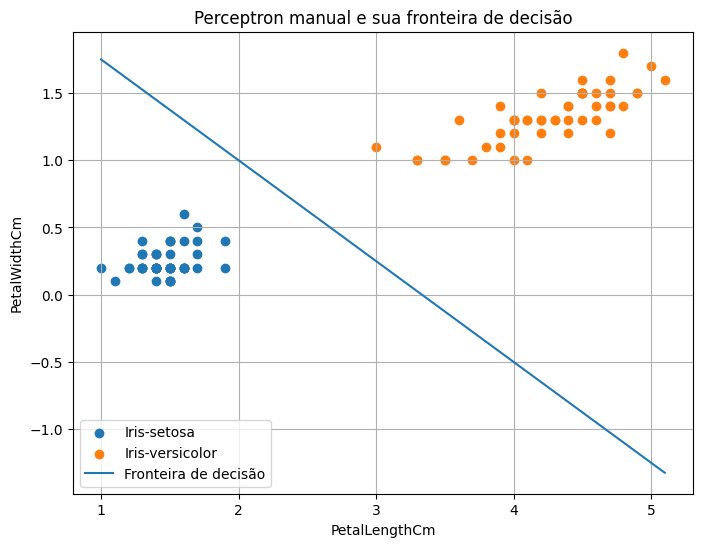

In [23]:
x_reta = [min(x_setosa + x_versicolor), max(x_setosa + x_versicolor)]

if pesos_finais[1] != 0:
    y_reta = []

    for x in x_reta:
        y = -(pesos_finais[0] * x + bias_final) / pesos_finais[1]
        y_reta.append(y)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_setosa, y_setosa, label="Iris-setosa")
    plt.scatter(x_versicolor, y_versicolor, label="Iris-versicolor")
    plt.plot(x_reta, y_reta, label="Fronteira de decisão")

    plt.xlabel("PetalLengthCm")
    plt.ylabel("PetalWidthCm")
    plt.title("Perceptron manual e sua fronteira de decisão")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Não foi possível desenhar a reta porque o segundo peso é zero.")


## Teste com novas amostras escolhidas manualmente

Esses exemplos ajudam a entender como o modelo se comporta em entradas específicas.


In [24]:
novas_amostras = [
    [1.5, 0.2],
    [1.7, 0.4],
    [4.2, 1.3],
    [4.8, 1.5],
    [2.8, 0.8]
]

for amostra in novas_amostras:
    classe_prevista, soma = prever(amostra, pesos_finais, bias_final)
    print("Amostra nova:", amostra)
    print("Soma:", round(soma, 4))
    print("Classe prevista:", classe_prevista)
    print("-" * 40)


Amostra nova: [1.5, 0.2]
Soma: 0.094
Classe prevista: 1
----------------------------------------
Amostra nova: [1.7, 0.4]
Soma: 0.066
Classe prevista: 1
----------------------------------------
Amostra nova: [4.2, 1.3]
Soma: -0.156
Classe prevista: 0
----------------------------------------
Amostra nova: [4.8, 1.5]
Soma: -0.208
Classe prevista: 0
----------------------------------------
Amostra nova: [2.8, 0.8]
Soma: -0.032
Classe prevista: 0
----------------------------------------


## Conclusão

Neste notebook foi implementado manualmente um **Perceptron com duas entradas e bias**, sem uso de NumPy ou bibliotecas de machine learning.

A base utilizada foi a **Iris**, e o problema foi adaptado para classificação binária entre:

- `Iris-setosa`
- `Iris-versicolor`

As entradas escolhidas foram:

- `PetalLengthCm`
- `PetalWidthCm`

Essas variáveis mostraram boa separação visual entre as classes. Após o treinamento, o Perceptron reduziu os erros rapidamente e alcançou **acurácia de 100%** na base utilizada.
